# Suturing Quality Scoring - Paper Artifacts (Ticket 06)

One command turns the scored cohort CSVs (ticket 05) into the paper's
tables and figures: the official Val metrics, the AI-vs-expert agreement
table, and the correlation/calibration/trainee-level figures. This notebook
runs that command and shows the results.

In [1]:
import sys
from pathlib import Path

def find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    return start

ROOT = find_root(Path.cwd())
sys.path.insert(0, str(ROOT))

from IPython.display import Image, display
from suture_scoring.artifacts import generate_all

SCORES_DIR = ROOT / "outputs"
VAL_XLSX = ROOT / "Dataset/Val/Validation_cohort/Validation_annotations.xlsx"
ARTIFACTS = ROOT / "artifacts"

In [2]:
produced = generate_all(
    SCORES_DIR,
    VAL_XLSX,
    ARTIFACTS,
    expert_labels_xlsx=ROOT / "outputs/demo-expert-2week.xlsx",  # placeholder until real labels arrive
)
print("\n".join(f"- {p.name}" for p in produced.values()))


- val-metrics.md
- scatter-grid.png
- calibration-grid.png
- trainee-levels.png
- agreement.md
- manifest.md


In [3]:
print((ARTIFACTS / "val-metrics.md").read_text())

## Val metrics (official split, final numbers)

| output | mae | exact | +/-1 | spearman | ece |
|---|---|---|---|---|---|
| Overall | 0.681 | 0.442 | 0.777 | 0.800 | 0.091 |
| ISD | 1.714 | 0.184 | 0.427 | 0.026 | 0.308 |
| Slack | 1.063 | 0.286 | 0.752 | 0.667 | 0.090 |
| Position | 1.063 | 0.282 | 0.743 | 0.464 | 0.118 |
| Angulation | 1.019 | 0.316 | 0.782 | 0.178 | 0.164 |
| Width | 0.791 | 0.374 | 0.854 | 0.442 | 0.173 |



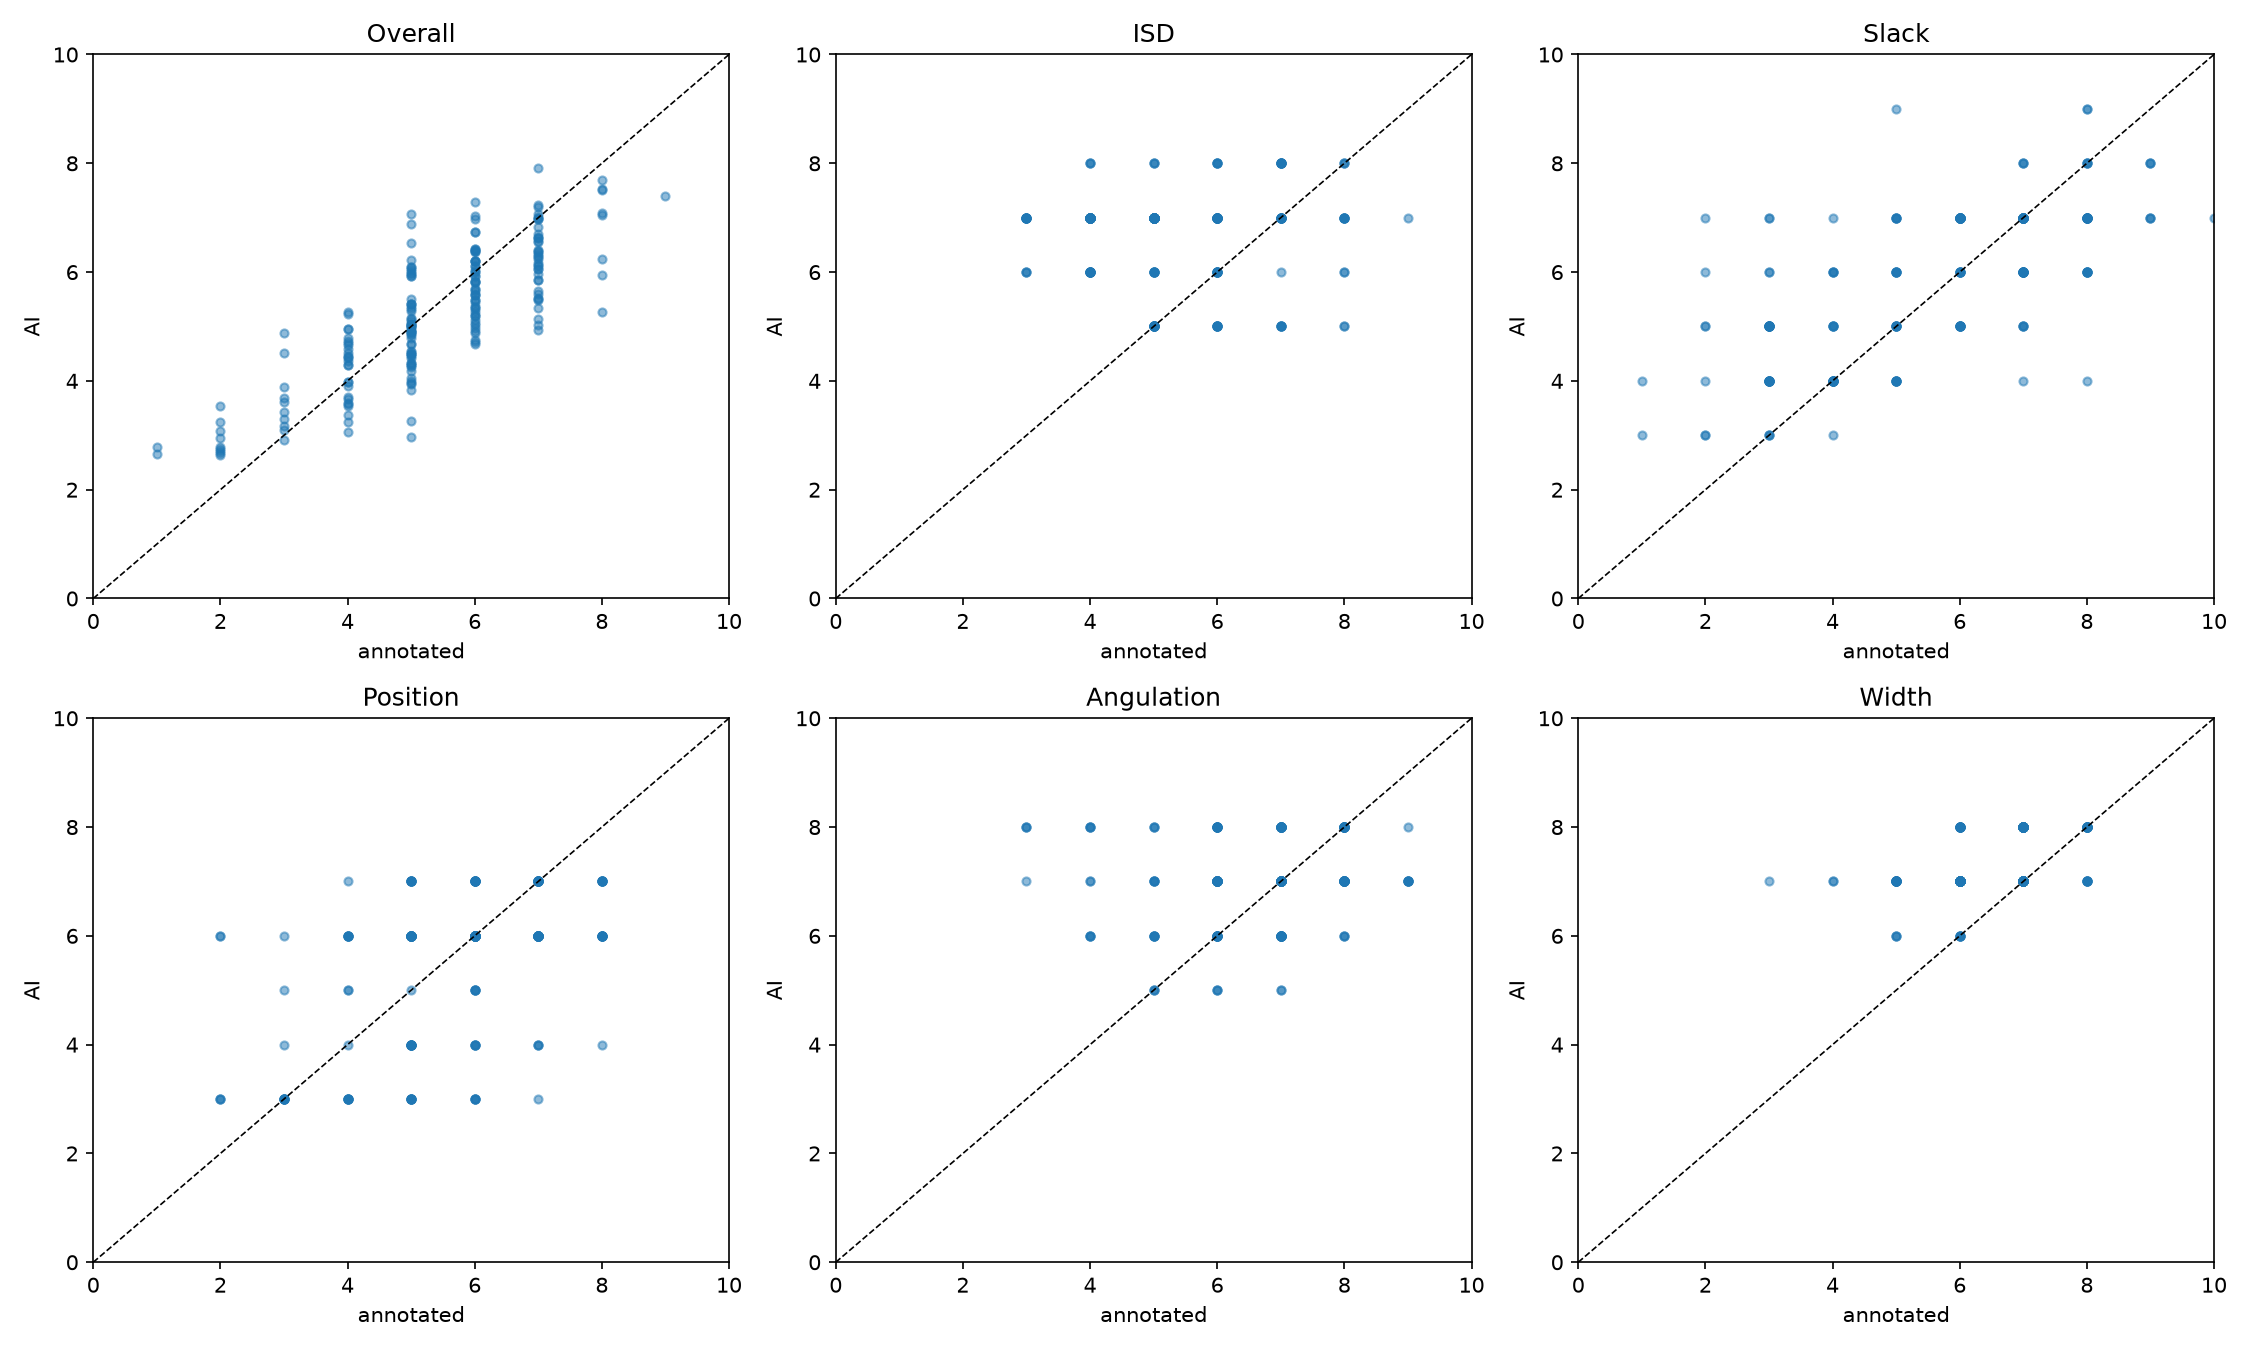

In [4]:
display(Image(filename=str(ARTIFACTS / "scatter-grid.png")))


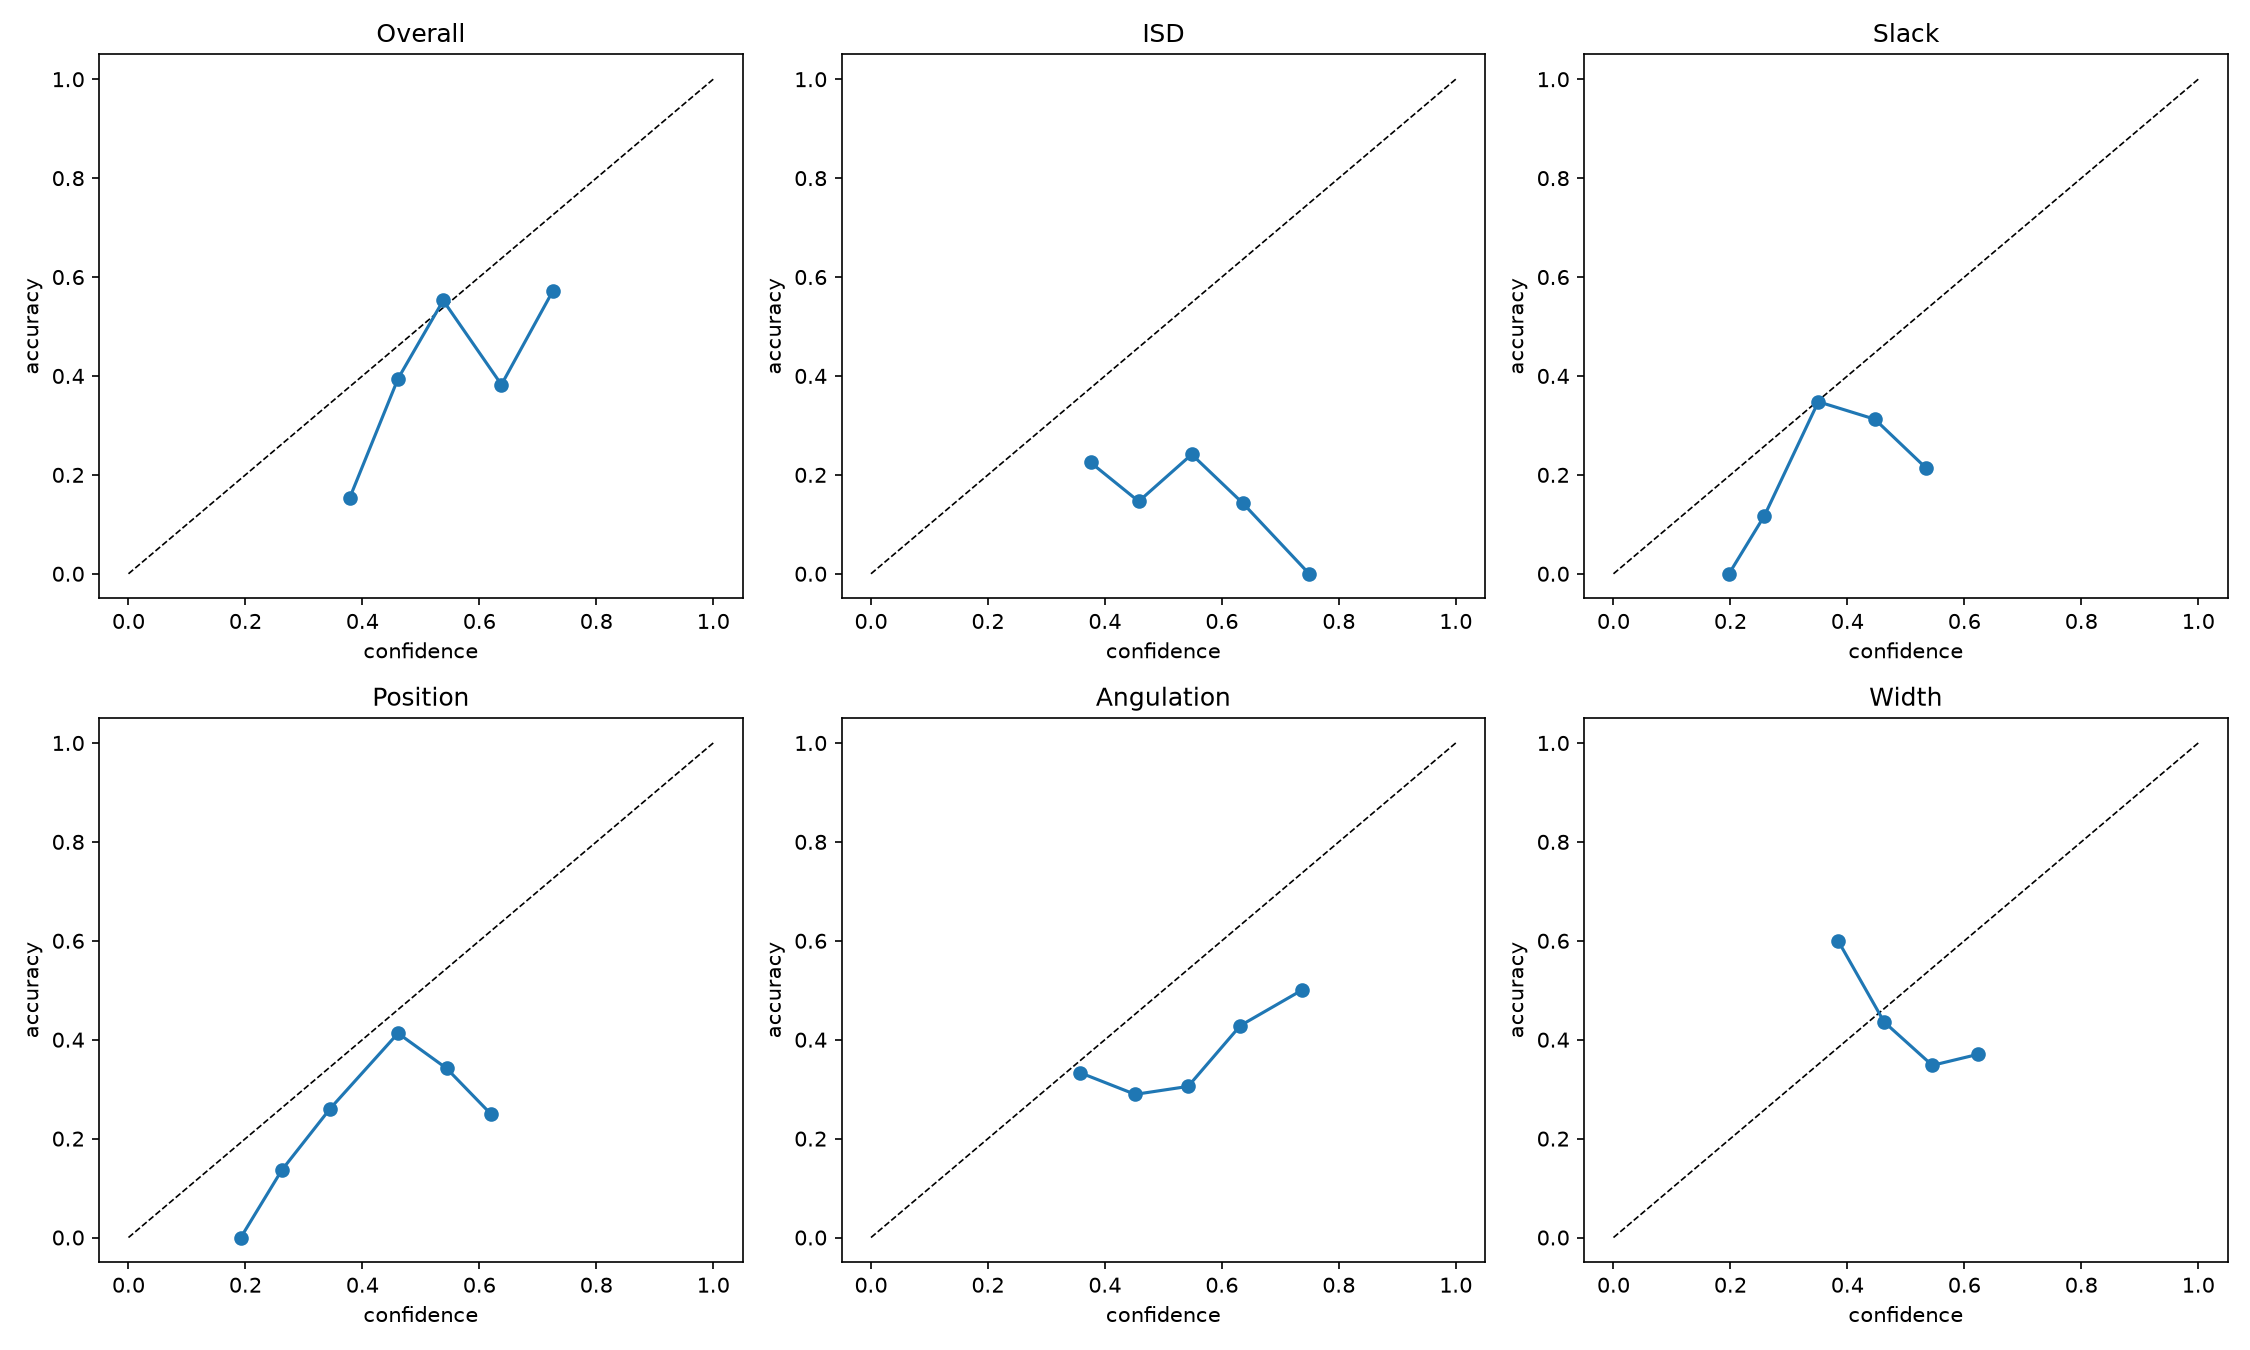

In [5]:
display(Image(filename=str(ARTIFACTS / "calibration-grid.png")))


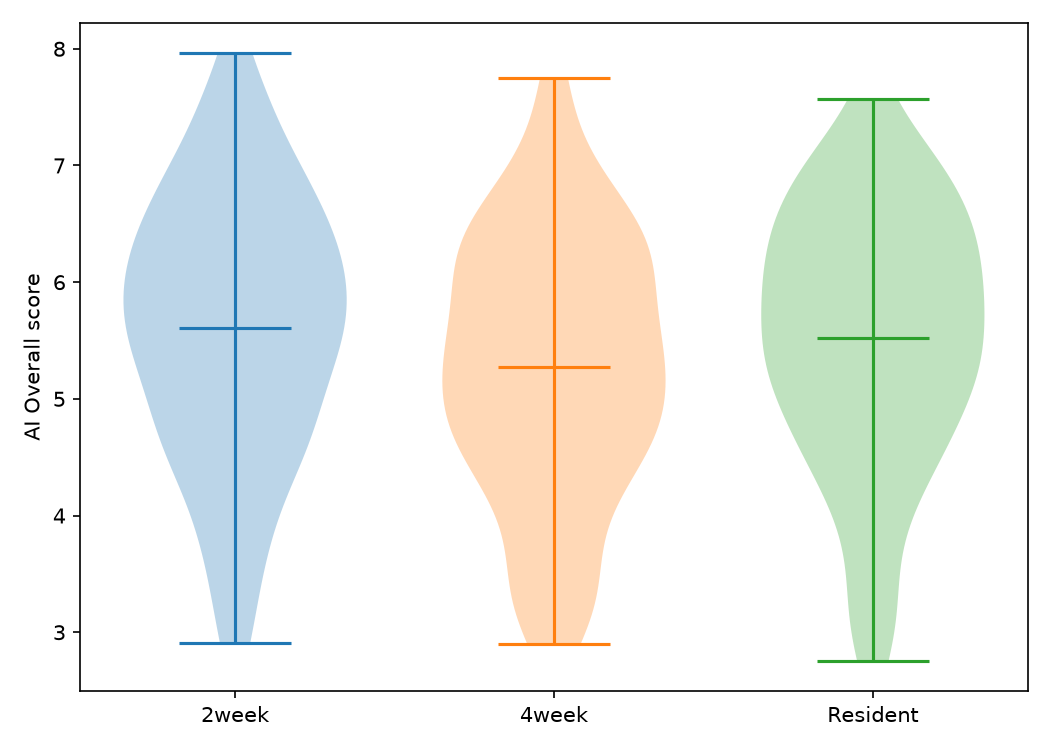

In [6]:
display(Image(filename=str(ARTIFACTS / "trainee-levels.png")))

In [7]:
print((ARTIFACTS / "agreement.md").read_text())

## AI-vs-expert agreement (per trainee level)

| level | output | icc | kappa |
|---|---|---|---|
| 2week | Overall | 0.232 | 0.231 |
| 2week | ISD | -0.125 | -0.124 |
| 2week | Slack | -0.044 | -0.044 |
| 2week | Position | 0.015 | 0.015 |
| 2week | Angulation | 0.004 | 0.004 |
| 2week | Width | 0.093 | 0.093 |
| 4week | Overall | 0.293 | 0.292 |
| 4week | ISD | -0.009 | -0.009 |
| 4week | Slack | 0.001 | 0.001 |
| 4week | Position | -0.007 | -0.007 |
| 4week | Angulation | -0.021 | -0.021 |
| 4week | Width | 0.016 | 0.016 |
| Resident | Overall | 0.141 | 0.140 |
| Resident | ISD | 0.018 | 0.018 |
| Resident | Slack | 0.042 | 0.042 |
| Resident | Position | -0.074 | -0.073 |
| Resident | Angulation | 0.001 | 0.001 |
| Resident | Width | 0.064 | 0.064 |



## Paper status

- `val-metrics.md` holds the official-split final numbers (MAE, exact, ±1,
  Spearman, ECE per output).
- `agreement.md` fills in automatically when real expert labels are supplied
  via `--expert-labels`; it currently reports the graceful not-yet-available
  path.
- All artifacts regenerate from `python -m suture_scoring artifacts
  --scores-dir outputs --val-annotations <val.xlsx> --output-dir artifacts
  [--expert-labels <labels.xlsx>]`.